# Category Dotplot: Aesthetics Tutorial

`scl.category_dotplot` draws a grouped dot-heatmap where rows are split into
`groupby` blocks (e.g. cell types) and each block holds one colored sub-row per
`category` level (e.g. condition / sample). Dot **size** encodes the fraction of
expressing cells; dot **color** is each category's own colormap applied to mean
expression.

A plain call already looks good — every knob below has a sensible default. This
notebook walks through the **aesthetic options** and shows what each one changes,
using a pancreatic-cancer fibroblast dataset (9 fibroblast subtypes × IPMN/PDAC).

> Built on `PyComplexHeatmap.DotClustermapPlotter` — an optional dependency:
> `pip install "sceleto[dotplot]"`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import scanpy as sc
import sceleto as scl

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# --- aesthetics ---
sc.settings.set_figure_params(facecolor="white", frameon=False)
sns.set_style("white")
sns.set_style("ticks")

plt.rcParams["pdf.fonttype"] = 42          # keep text editable in exported PDFs
plt.rcParams.update({                        # black text / axes throughout
    "text.color": "black",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})
mpl.rcParams.update({
    "lines.color": "black",
    "patch.edgecolor": "black",
})

## Data

`adata.X` here is scaled (z-scored), so expression is read from `adata.raw`
(`use_raw=True`, the default). We use `anno_final` (cell type) as `groupby` and
`pathol` (IPMN vs PDAC) as `category`.

In [ ]:
adata = sc.read_h5ad(...)   # <- your .h5ad (cells × genes, with celltype & condition in .obs)

print(adata.shape)
print("groupby  anno_final:", list(adata.obs["anno_final"].cat.categories))
print("category pathol    :", list(adata.obs["pathol"].cat.categories))

In [3]:
# A marker panel. Passing a *dict* splits the x-axis into gene groups (col_split);
# passing a flat list would give a single ungrouped row of genes.
panel = {
    "Pan-Fib": ["PDGFRA", "PDGFRB", "COL1A1", "DCN", "LUM"],
    "myCAF":   ["ACTA2", "TAGLN", "POSTN", "LRRC15"],
    "iCAF":    ["IL6", "CXCL12", "CCL2", "SFRP1"],
    "cycling": ["MKI67", "MSLN", "STRA6", "VIT"],
}

## 1. The default call

No styling arguments needed — the defaults give: color = raw log1p mean (per-category
colormap), size = % expressing cells, a rectangular colorbar with round tick numbers,
a thin black dot outline, borderless legends, compact columns, cell-type names on the
left, and x labels rotated 90°. The groupby sidebar reuses
`adata.uns['anno_final_colors']` when present.

Plotting HeatmapAnnotations


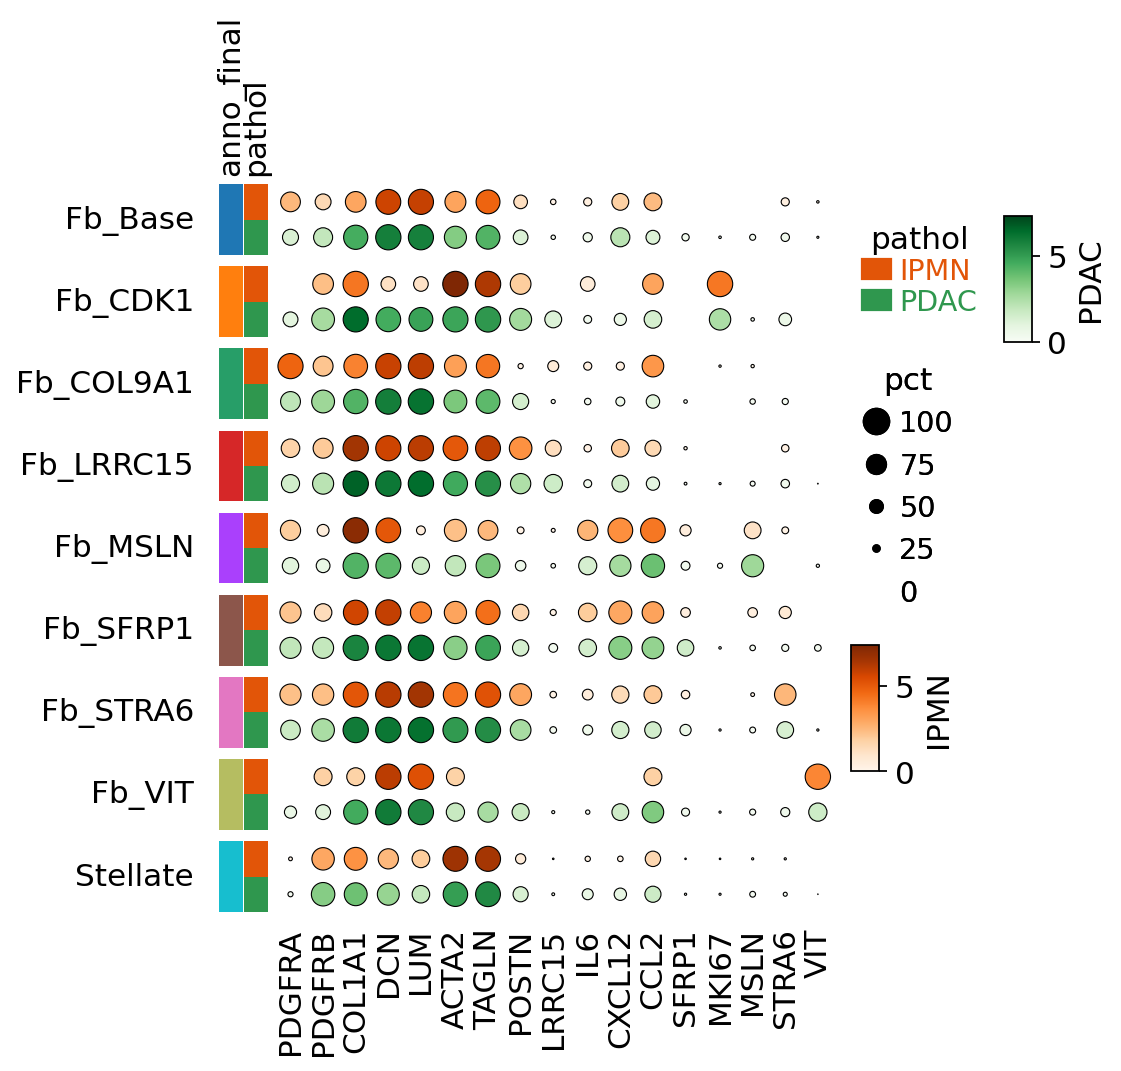

In [4]:
fig, cm = scl.category_dotplot(adata, panel, groupby="anno_final", category="pathol")

## 2. What the dot *color* encodes

| argument | color meaning | range |
|---|---|---|
| *(default)* | raw log1p mean expression | auto (data) |
| `max_scale=True` | per-gene max-normalised mean, **within each category** (no negatives) | 0..1 |
| `standard_scale='var'` | z-score per gene | −2..2 |
| `standard_scale='group'` | z-score per row | −2..2 |
| `vmin=`, `vmax=` | clamp the color limits | manual |

`max_scale` and `standard_scale` are mutually exclusive. `max_scale` normalises
each gene against *that category's* own maximum, so every category's colormap
uses its full 0..1 range (a low-expression category isn't washed out by a
high-expression one).

Plotting HeatmapAnnotations


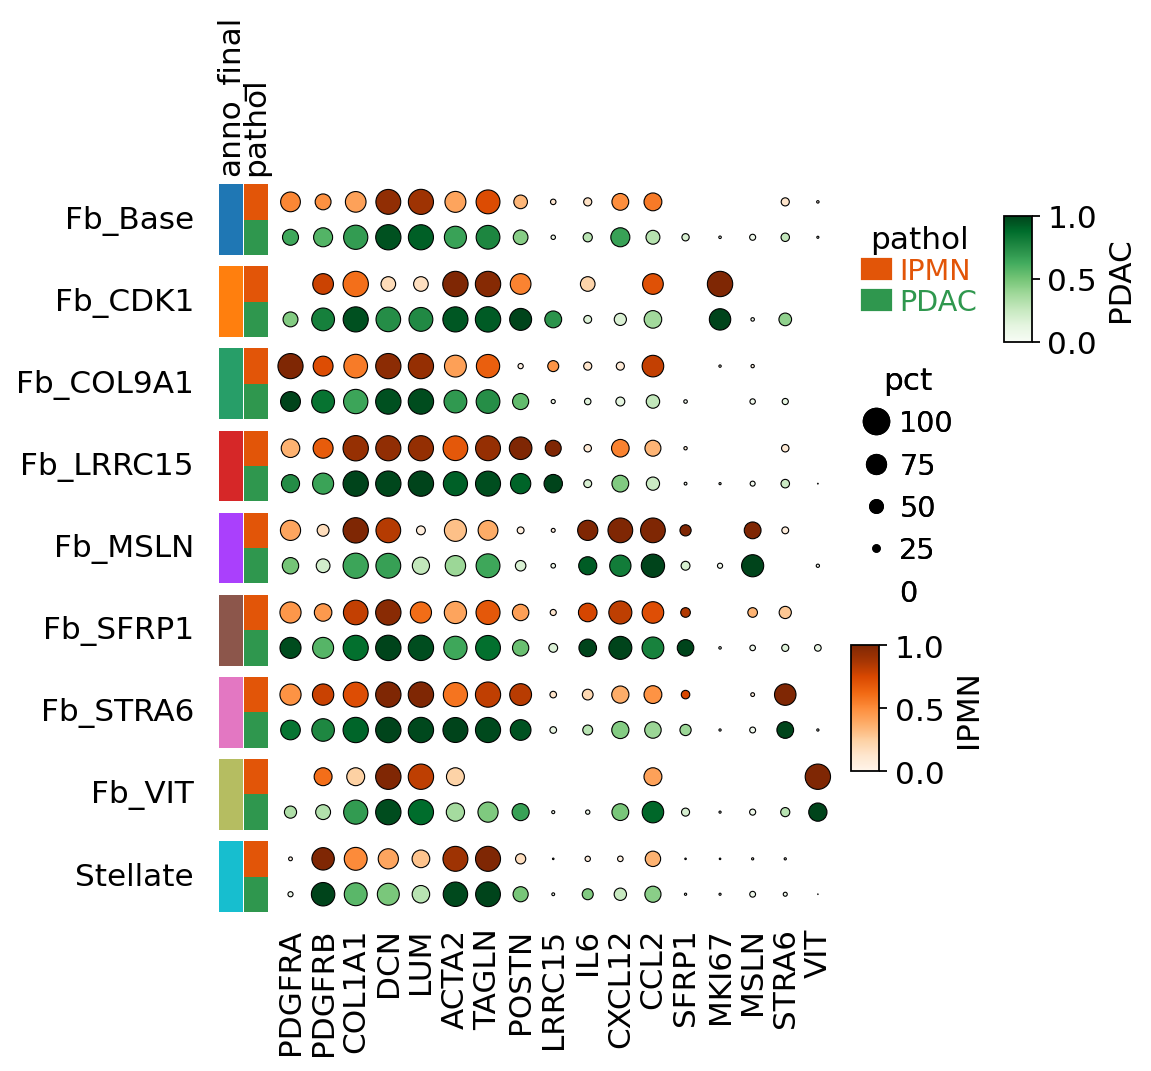

In [5]:
# per-gene max-normalised mean (0..1) — the same scaling as scl.dotplot(max_scale=True)
fig, cm = scl.category_dotplot(adata, panel, groupby="anno_final", category="pathol",
                               max_scale=True)

Plotting HeatmapAnnotations


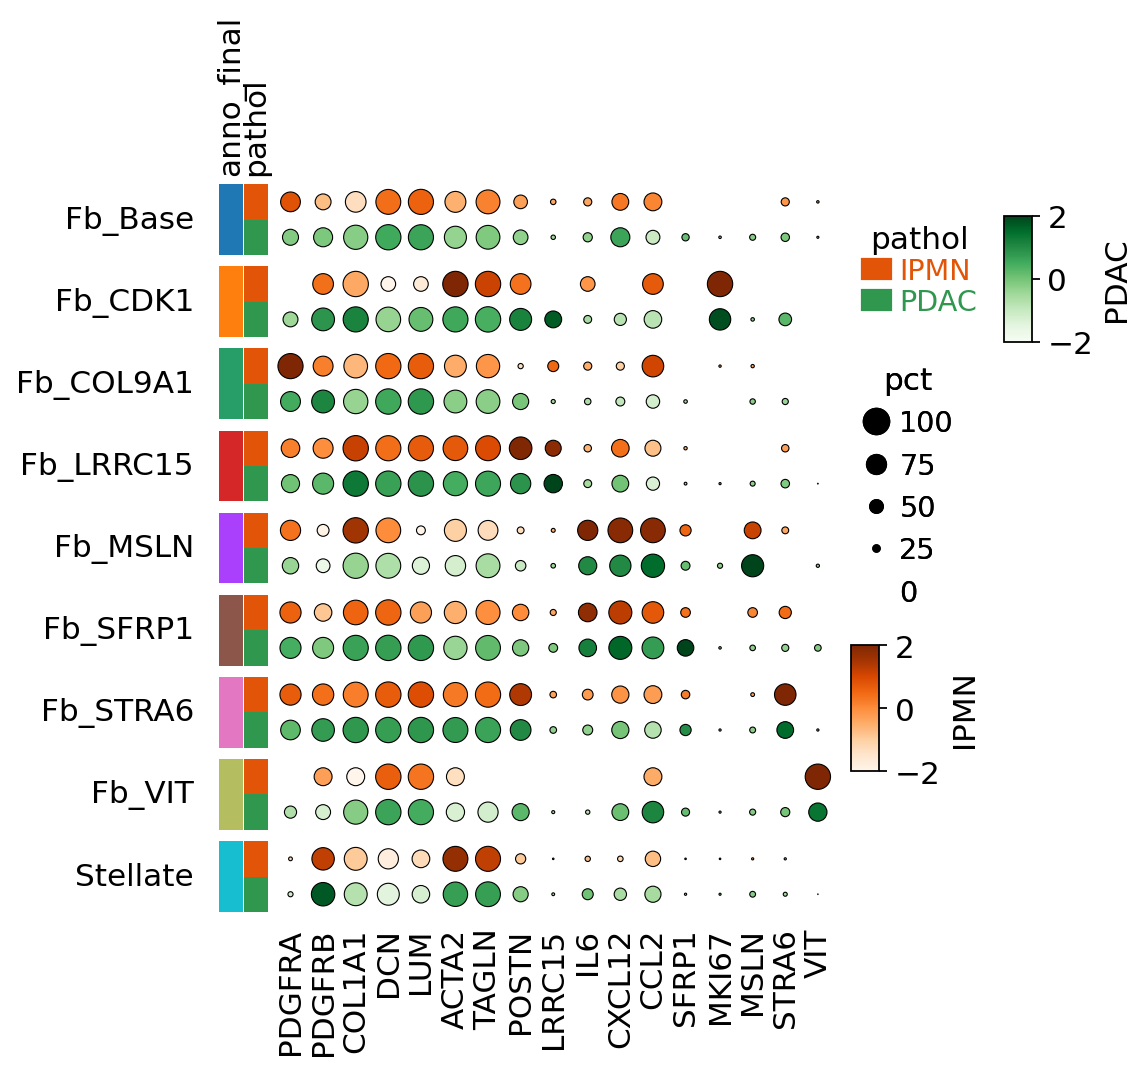

In [6]:
# z-score each gene across rows (diverging)
fig, cm = scl.category_dotplot(adata, panel, groupby="anno_final", category="pathol",
                               standard_scale="var")

Plotting HeatmapAnnotations


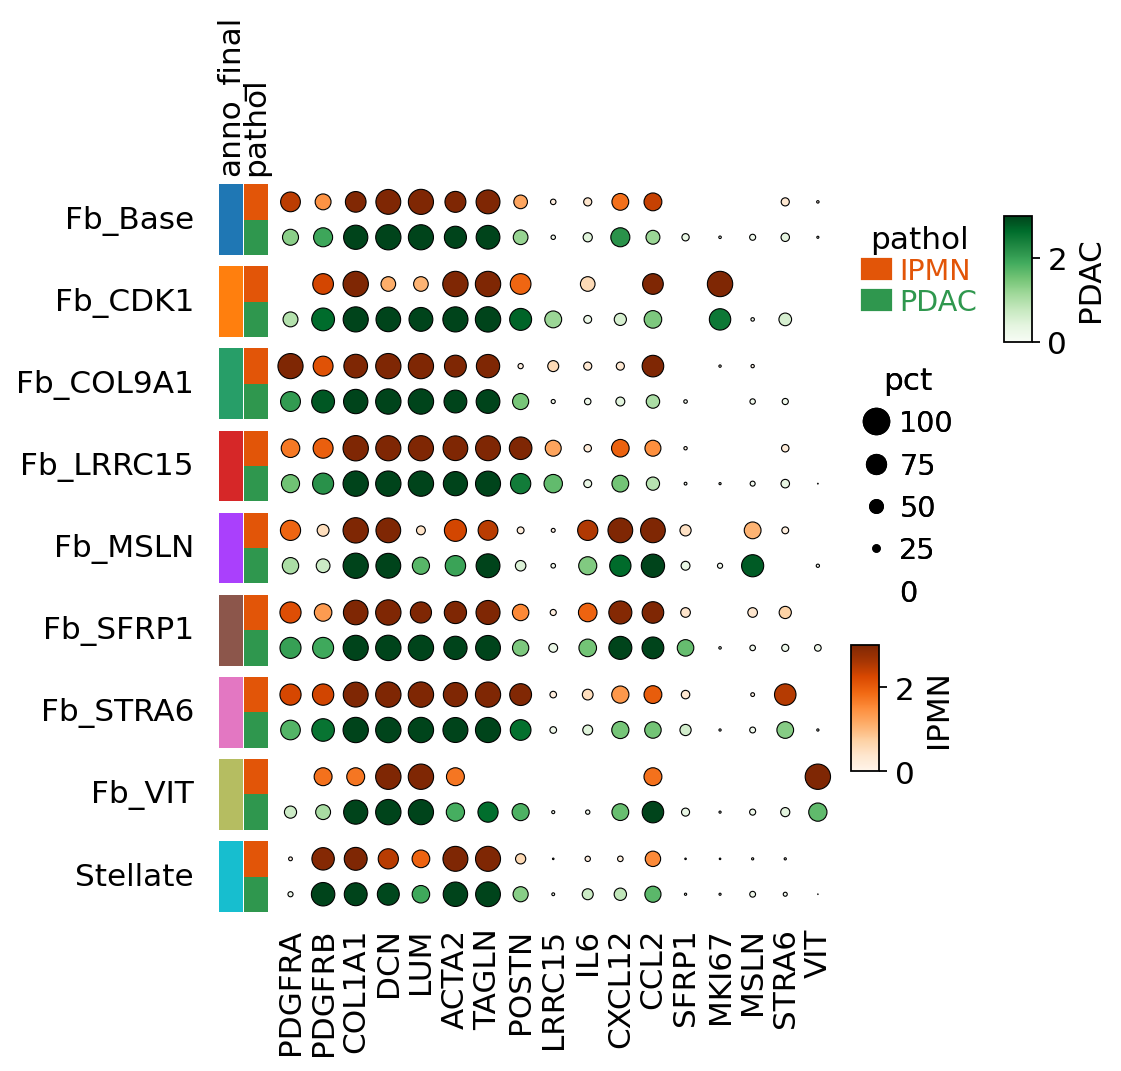

In [7]:
# clamp the raw-mean color range manually
fig, cm = scl.category_dotplot(adata, panel, groupby="anno_final", category="pathol",
                               vmin=0, vmax=3)

## 3. Per-category colormaps & sidebar colors

Each `category` level gets its own colormap. By default, if
`adata.uns['{category}_colors']` exists a light→that-color gradient is built per
level; otherwise a distinct sequential palette is cycled
(Oranges / Greens / Greys / …). Override with `category_cmaps` (a dict keyed by
category level, or a list cycled over levels).

The `groupby` sidebar colors come from `adata.uns['{groupby}_colors']` when present;
override with `group_colors={level: color}`.

Plotting HeatmapAnnotations


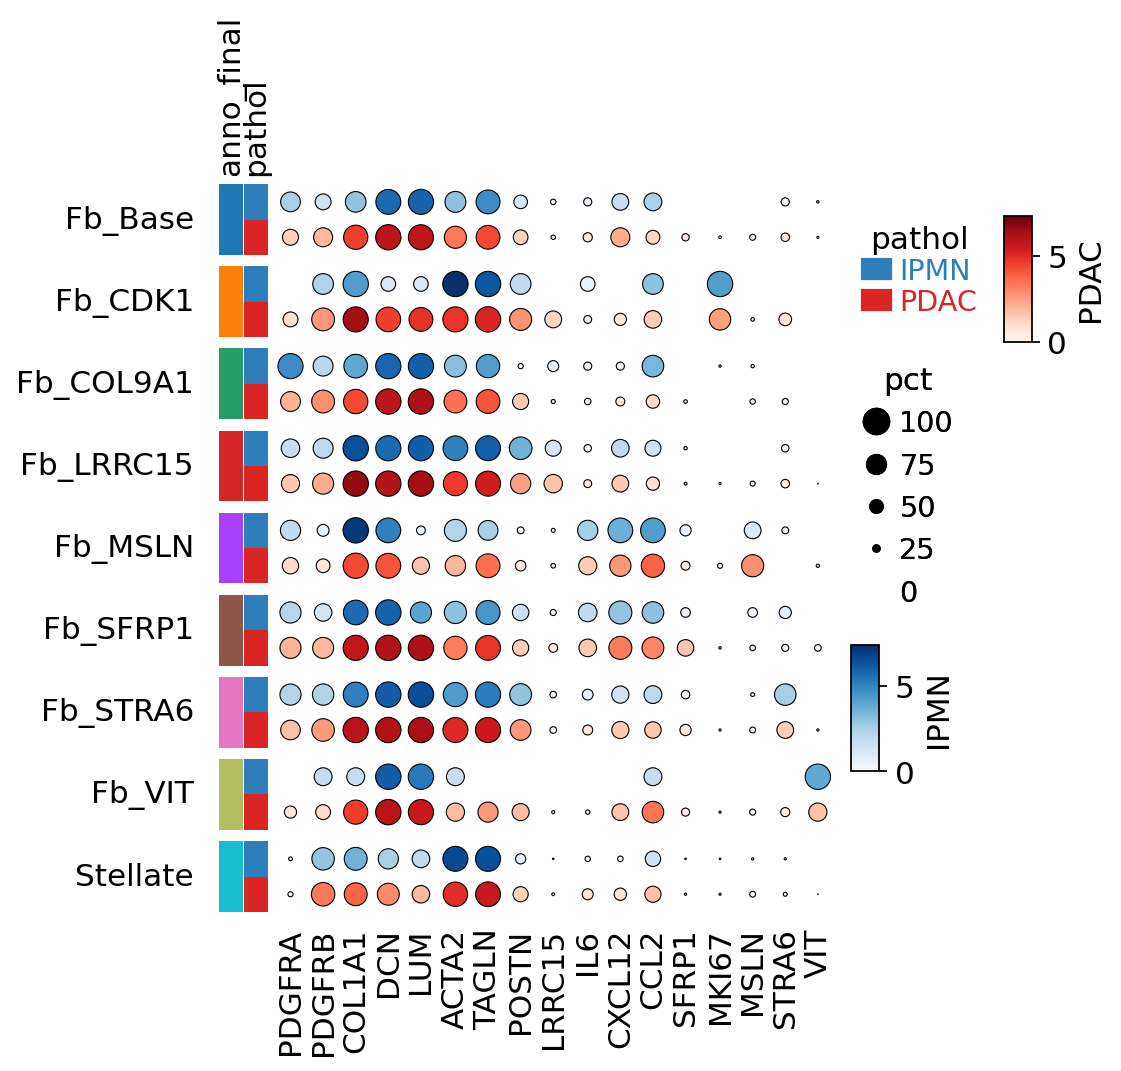

In [8]:
# custom per-category colormaps
fig, cm = scl.category_dotplot(adata, panel, groupby="anno_final", category="pathol",
                               category_cmaps={"IPMN": "Blues", "PDAC": "Reds"})

## 4. Dots — outline & size

Dots carry a thin outline by default (`edgecolors="black"`, `linewidth=0.5`).
These are matplotlib `scatter` kwargs, so pass them straight through (singular
aliases `edgecolor` / `linewidth` and plural `edgecolors` / `linewidths` both work).

- `max_s` — largest dot area
- `min_s` — smallest dot area (default `0` → a value at the low end draws no dot,
  like `scanpy.pl.dotplot`; raise it to keep low values faintly visible)
- `dot_size='pct'` (default, % expressing) or `'mean'` (mean expression)
- `size_range=(low, high)` — pin the dot-size scale. By default the low end is 0
  and the high end is the observed max rounded up to the next 10 % (the
  `scanpy.pl.dotplot` convention), so the largest dot = the top % in *this* plot.
  Pass `size_range=(0, 100)` for absolute fractions comparable across plots.

Plotting HeatmapAnnotations


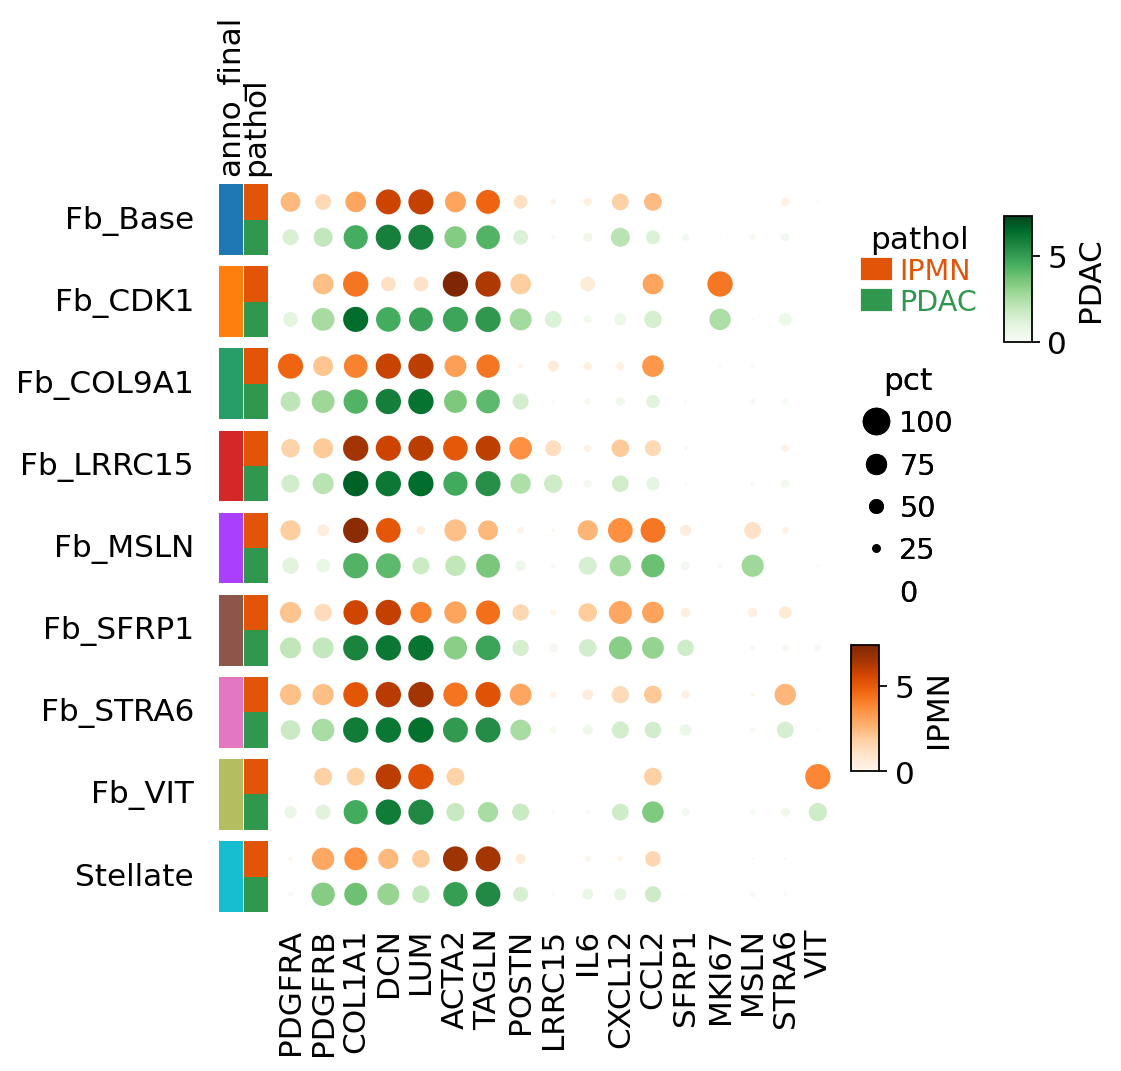

Plotting HeatmapAnnotations


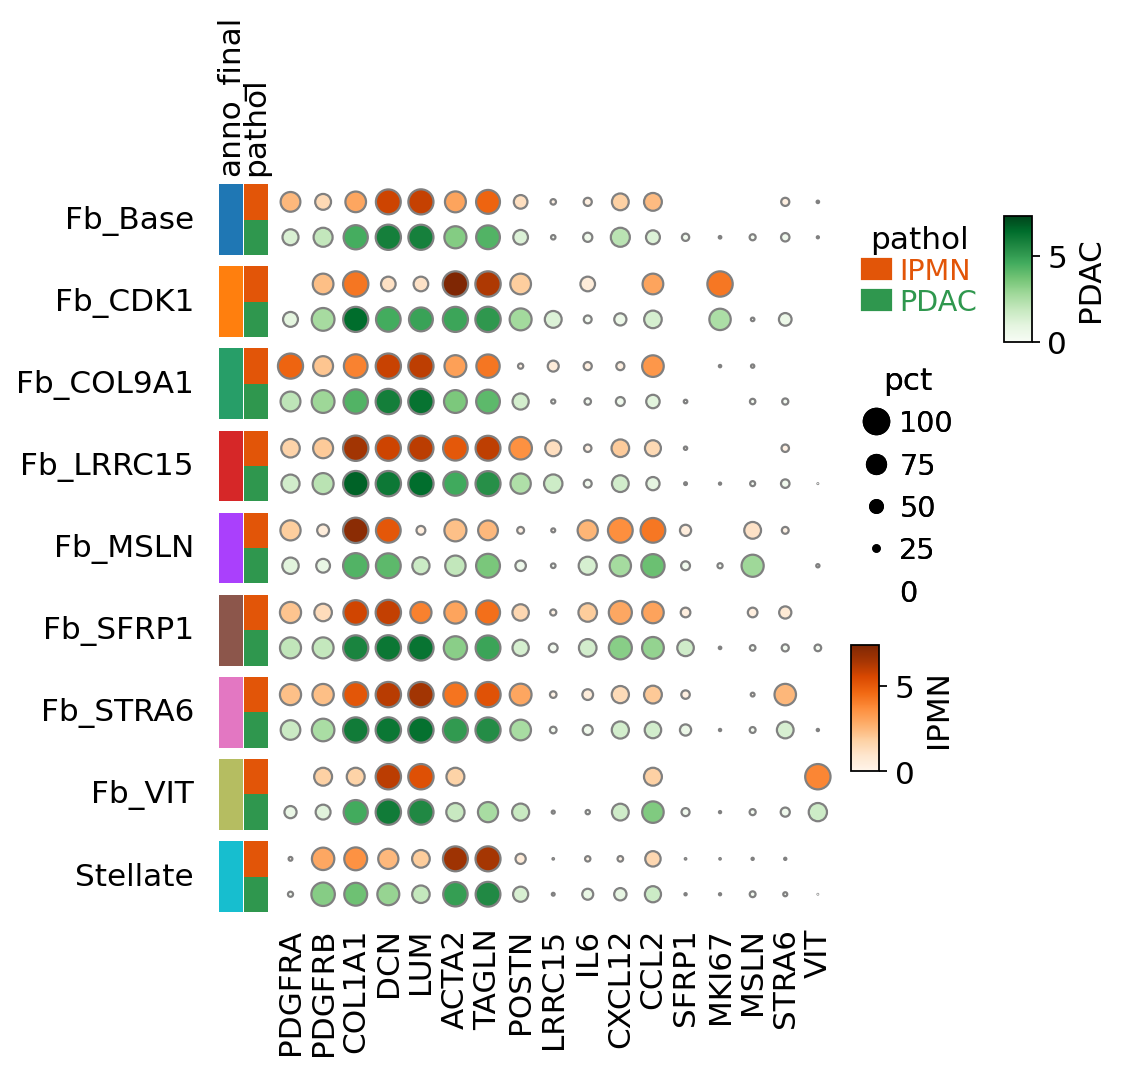

In [9]:
# no outline
fig, cm = scl.category_dotplot(adata, panel, groupby="anno_final", category="pathol",
                               edgecolors="none")

# thicker grey outline
fig, cm = scl.category_dotplot(adata, panel, groupby="anno_final", category="pathol",
                               edgecolors="grey", linewidth=1.0)

Plotting HeatmapAnnotations


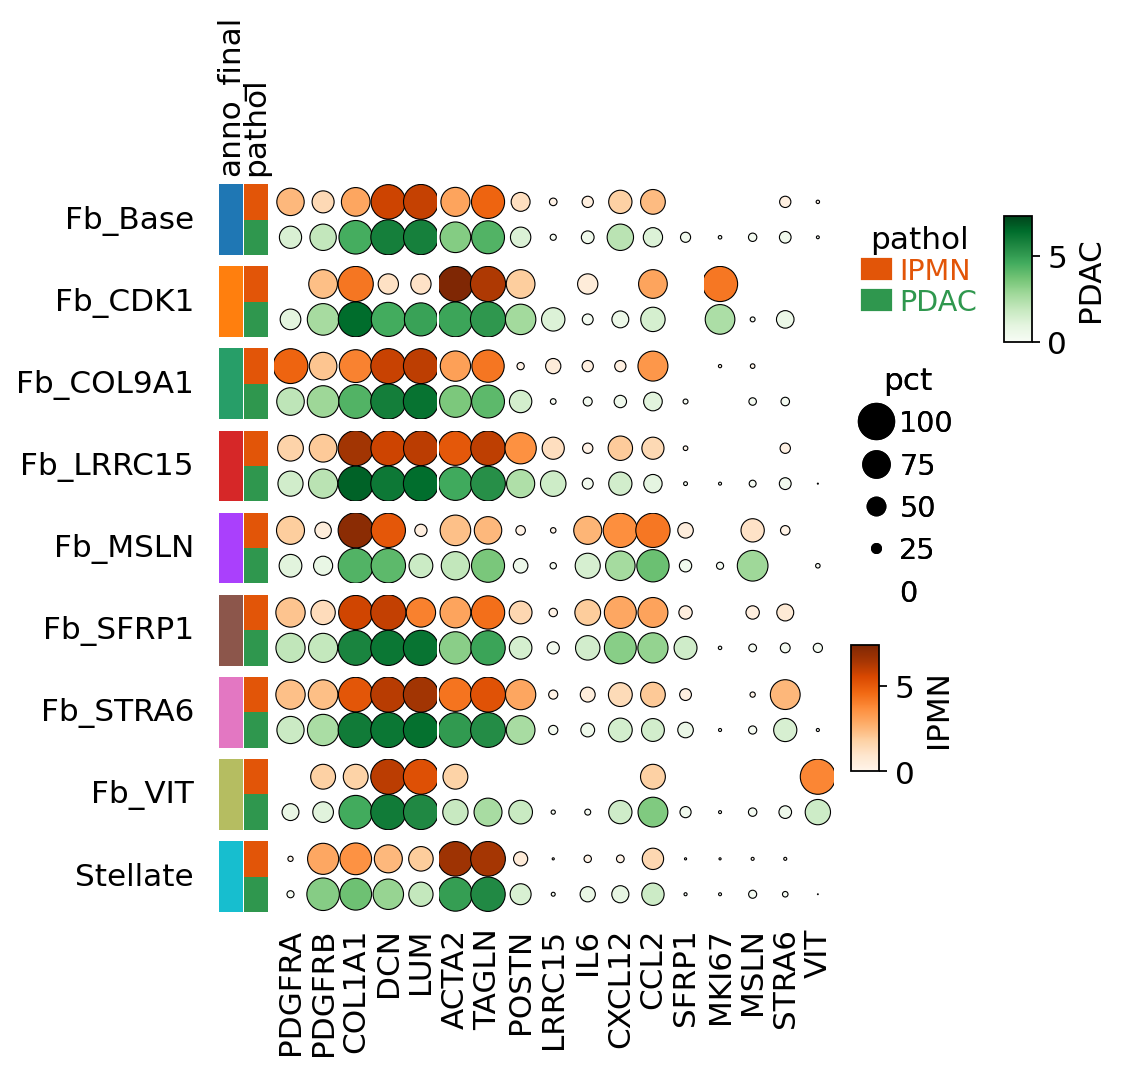

Plotting HeatmapAnnotations


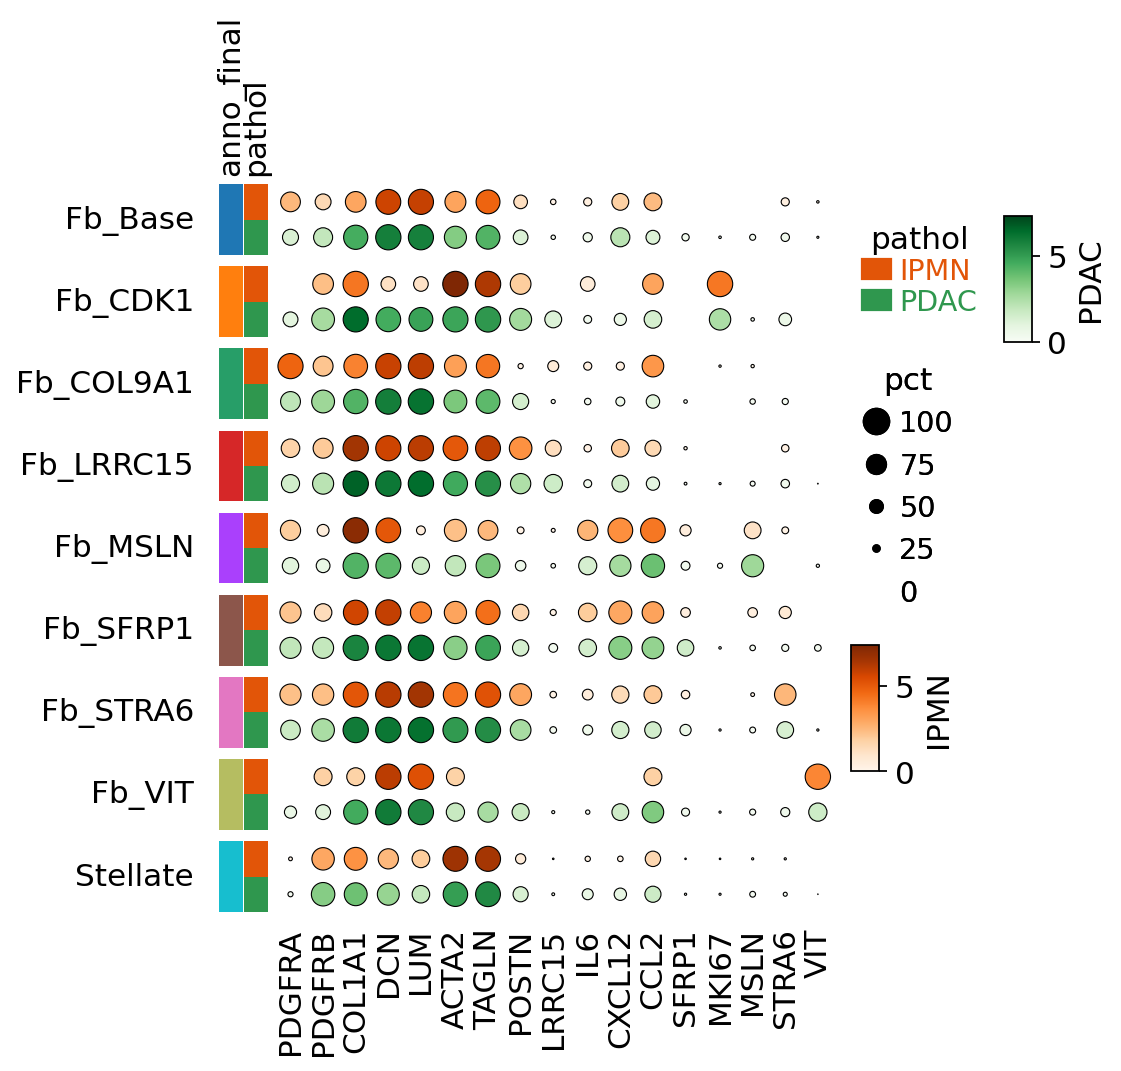

In [10]:
# bigger dots
fig, cm = scl.category_dotplot(adata, panel, groupby="anno_final", category="pathol",
                               max_s=250)

# absolute 0–100% size scale (comparable across plots) instead of the
# scanpy-style data-relative default
fig, cm = scl.category_dotplot(adata, panel, groupby="anno_final", category="pathol",
                               size_range=(0, 100))

## 5. Layout & spacing

- `row_split_gap` — gap between `groupby` blocks
- `col_split_gap` — gap between genes / gene groups
- `figsize` — manual `(width, height)` (auto-sized otherwise)
- `drop_empty=True` — hide empty `groupby`×`category` combos (useful when a
  `category` has many levels, e.g. per-sample)

Plotting HeatmapAnnotations


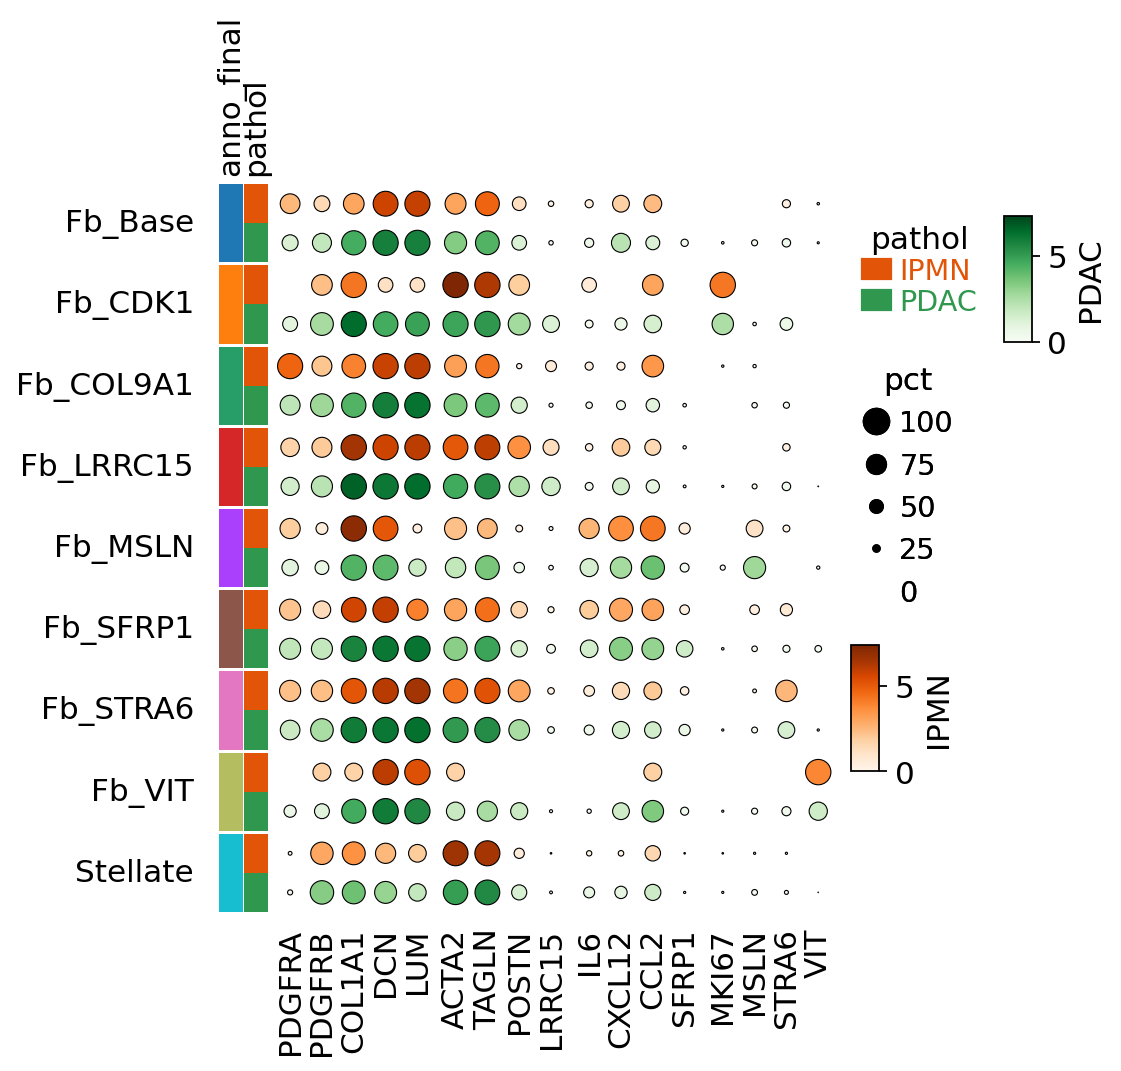

In [11]:
# tighter rows, wider column gaps
fig, cm = scl.category_dotplot(adata, panel, groupby="anno_final", category="pathol",
                               row_split_gap=0.4, col_split_gap=1.0)

Plotting HeatmapAnnotations


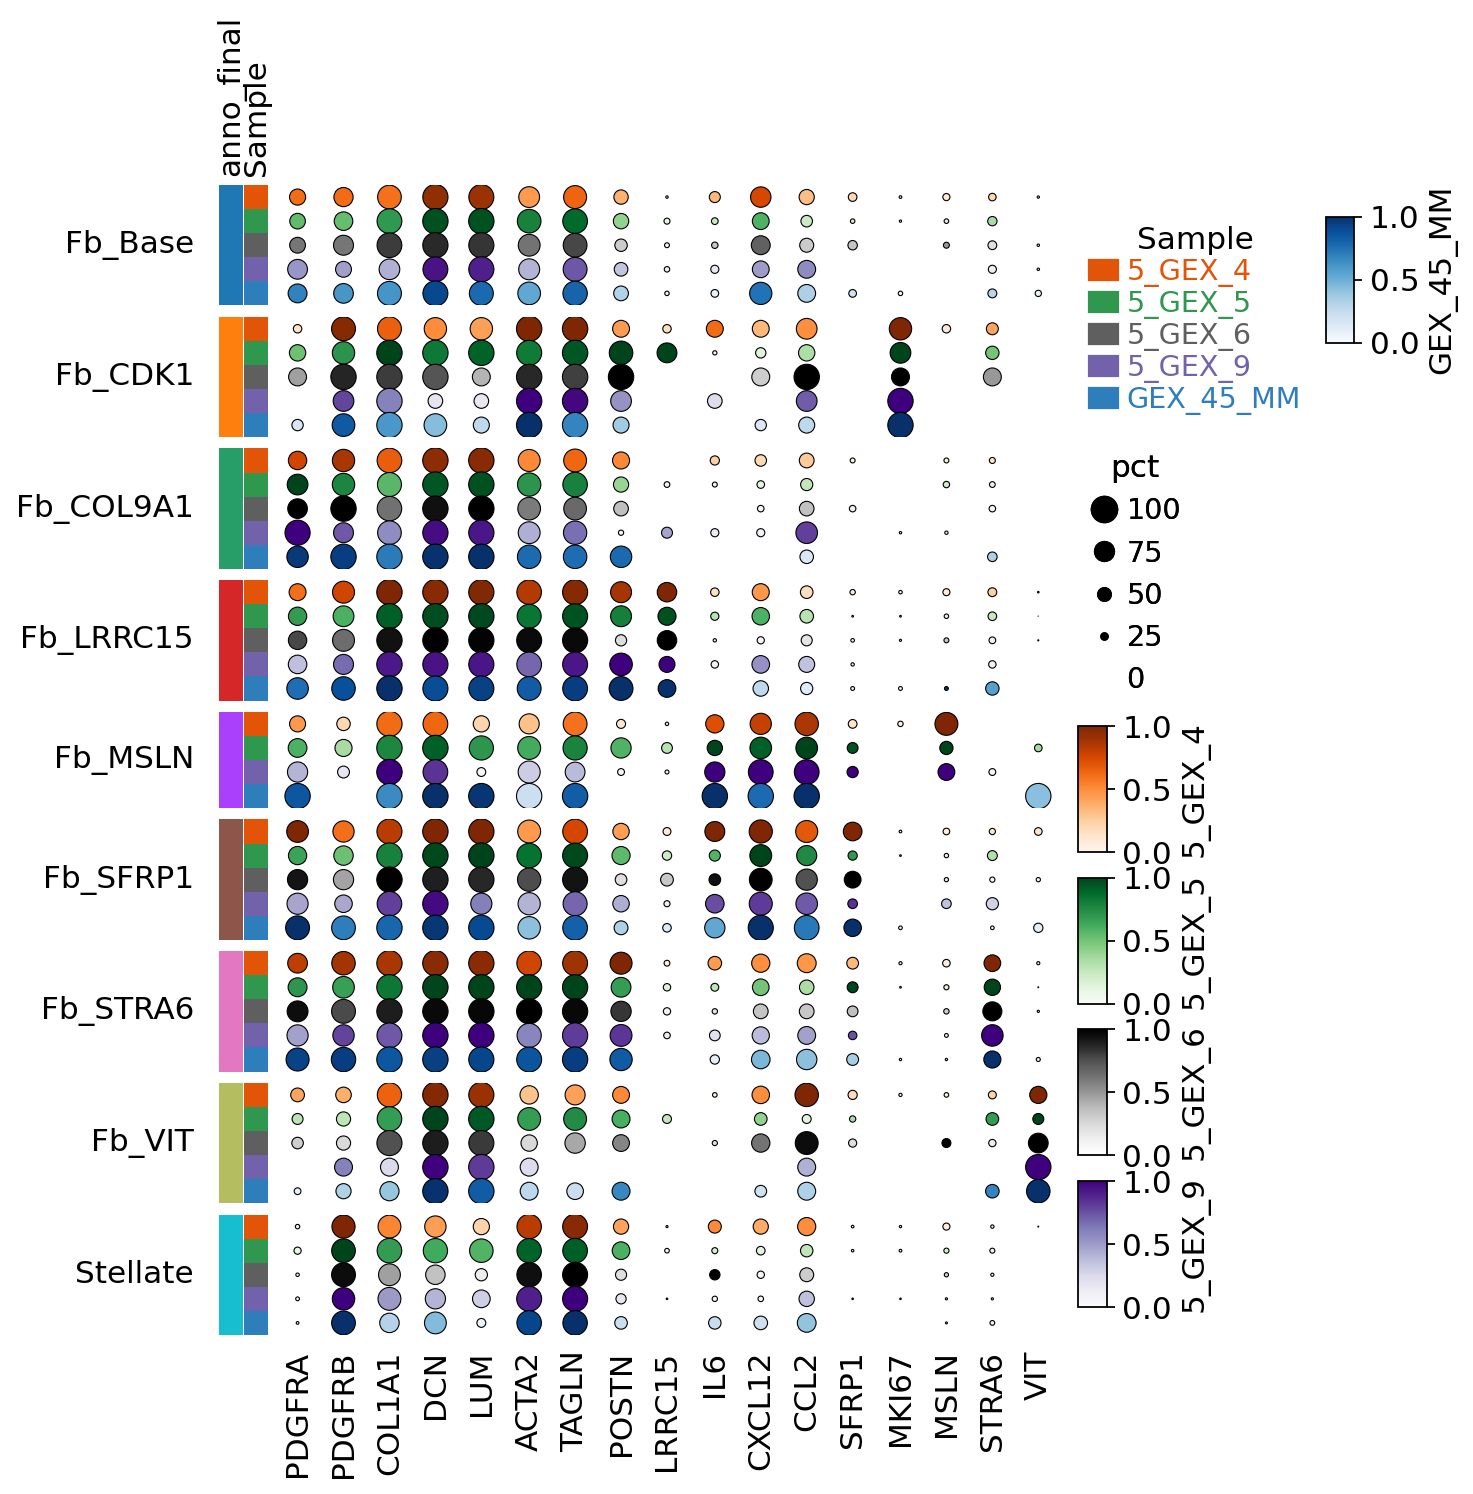

In [12]:
# many category levels (per sample): drop_empty hides combos with no cells
fig, cm = scl.category_dotplot(adata, panel, groupby="anno_final", category="Sample",
                               drop_empty=True, max_scale=True,
                               figsize=(7, 8))

## 6. Labels, ticks & legends

- x tick angle: `xticklabels_kws={"labelrotation": ...}` (PyComplexHeatmap honours
  `labelrotation`, **not** `rotation`; default 90)
- colorbar ticks: `cmap_legend_kws={"ticks": [...]}` or `{"format": "%.2f"}`
  (default `ticks=None` → matplotlib picks round numbers, the scanpy look)
- `show_rownames=True` — label every `group | category` sub-row
- `legend_width=` — legend column width in mm; `frameon` via `*_legend_kws`
- `show_group_label=False` / `sidebar=False` — drop the left annotations

Plotting HeatmapAnnotations


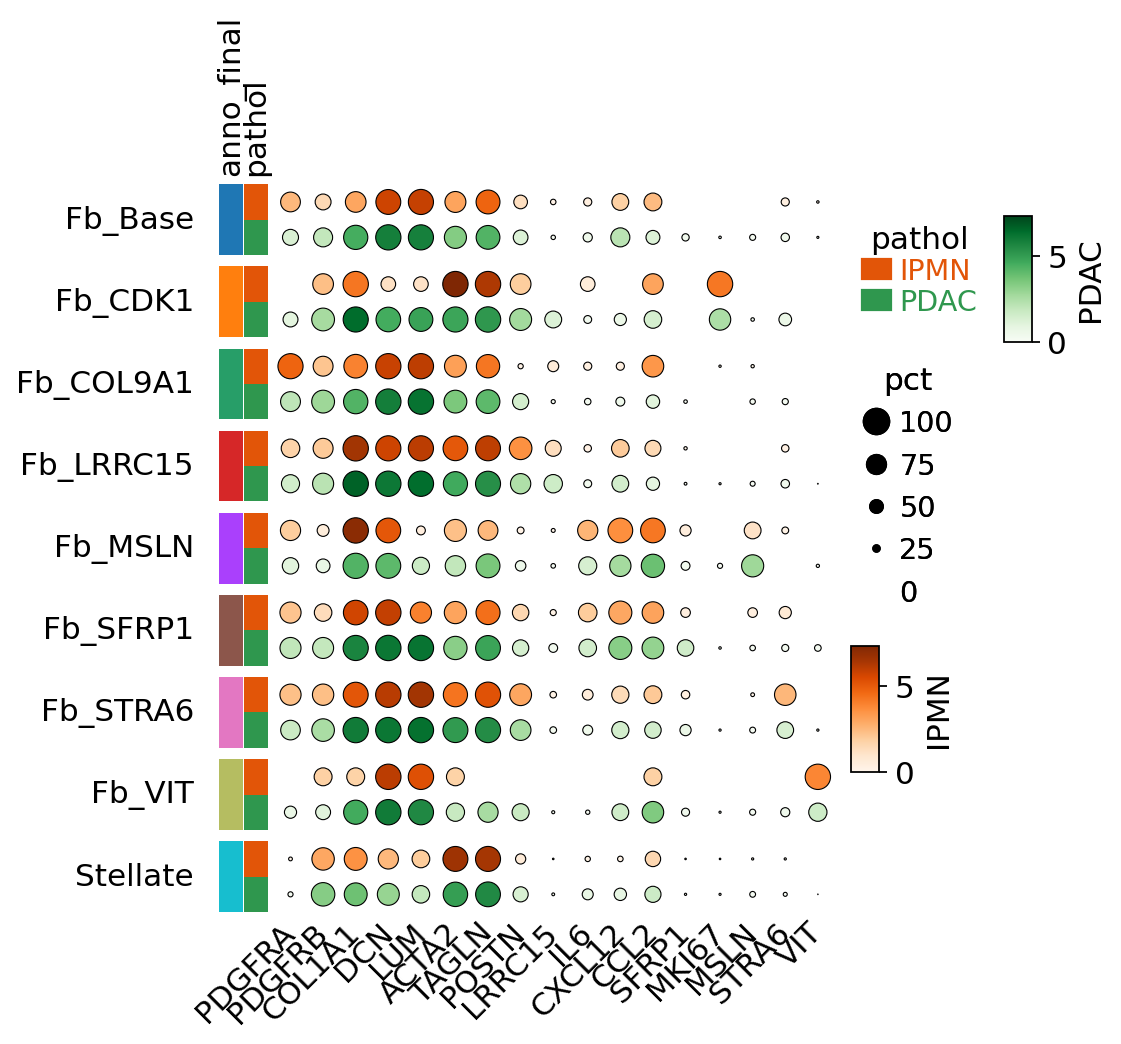

In [13]:
# 45° gene labels
fig, cm = scl.category_dotplot(adata, panel, groupby="anno_final", category="pathol",
                               xticklabels_kws={"labelrotation": 45})

Plotting HeatmapAnnotations


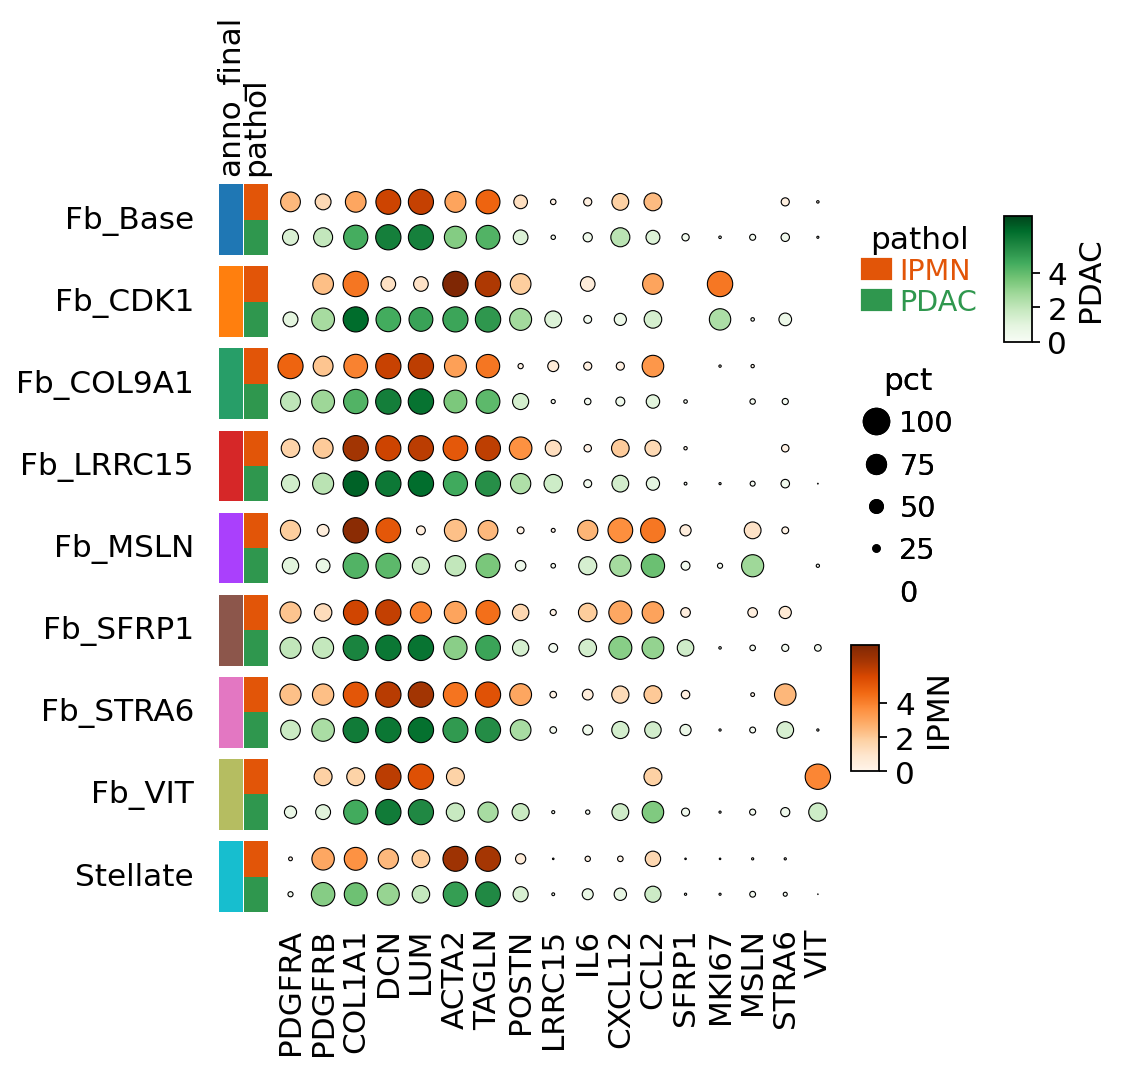

Plotting HeatmapAnnotations


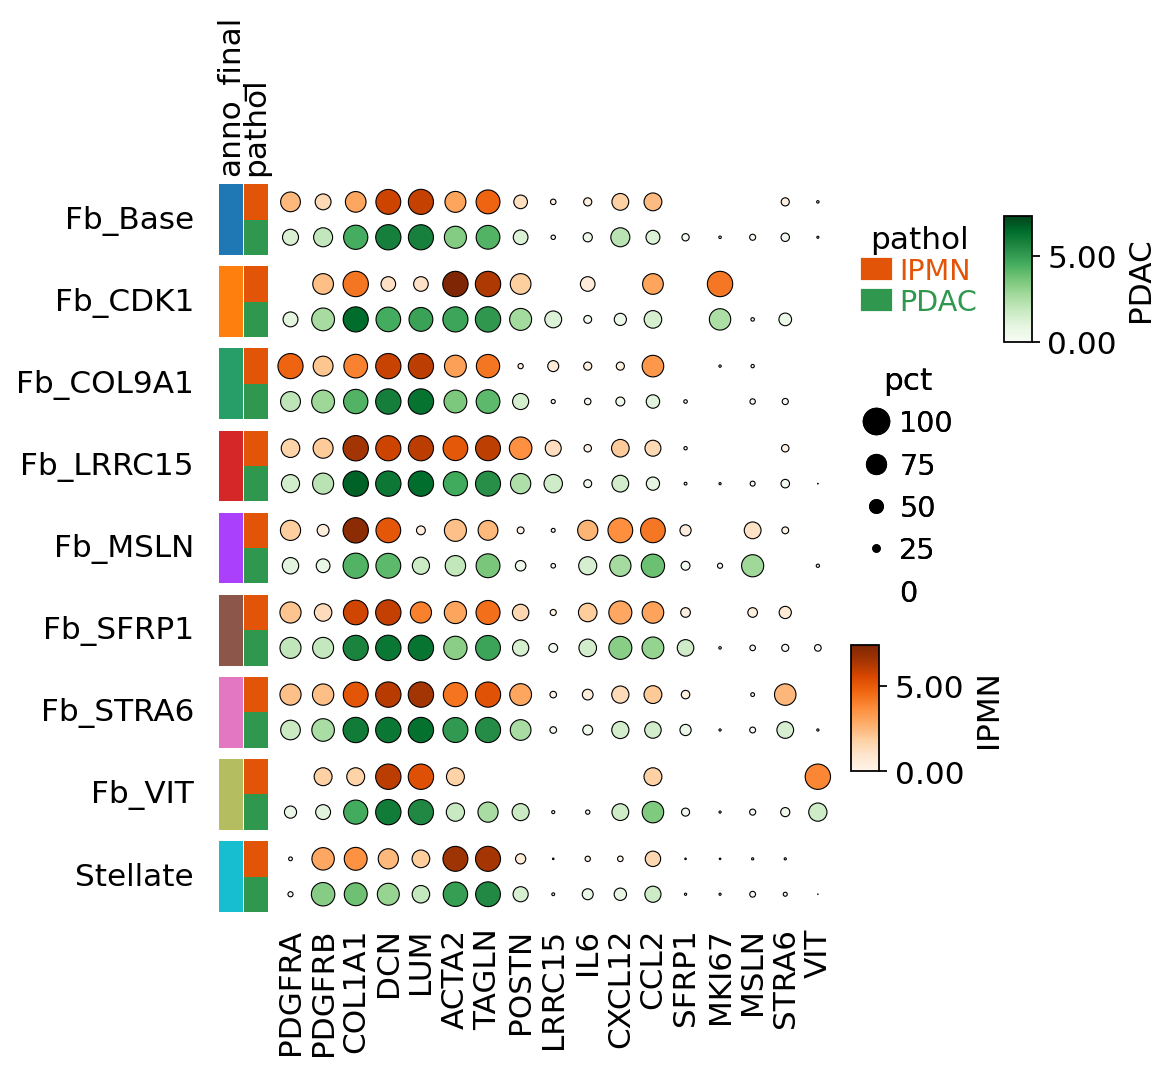

In [14]:
# explicit colorbar ticks
fig, cm = scl.category_dotplot(adata, panel, groupby="anno_final", category="pathol",
                               cmap_legend_kws={"ticks": [0, 2, 4]})

# or just control the number format
fig, cm = scl.category_dotplot(adata, panel, groupby="anno_final", category="pathol",
                               cmap_legend_kws={"format": "%.2f"})

Plotting HeatmapAnnotations


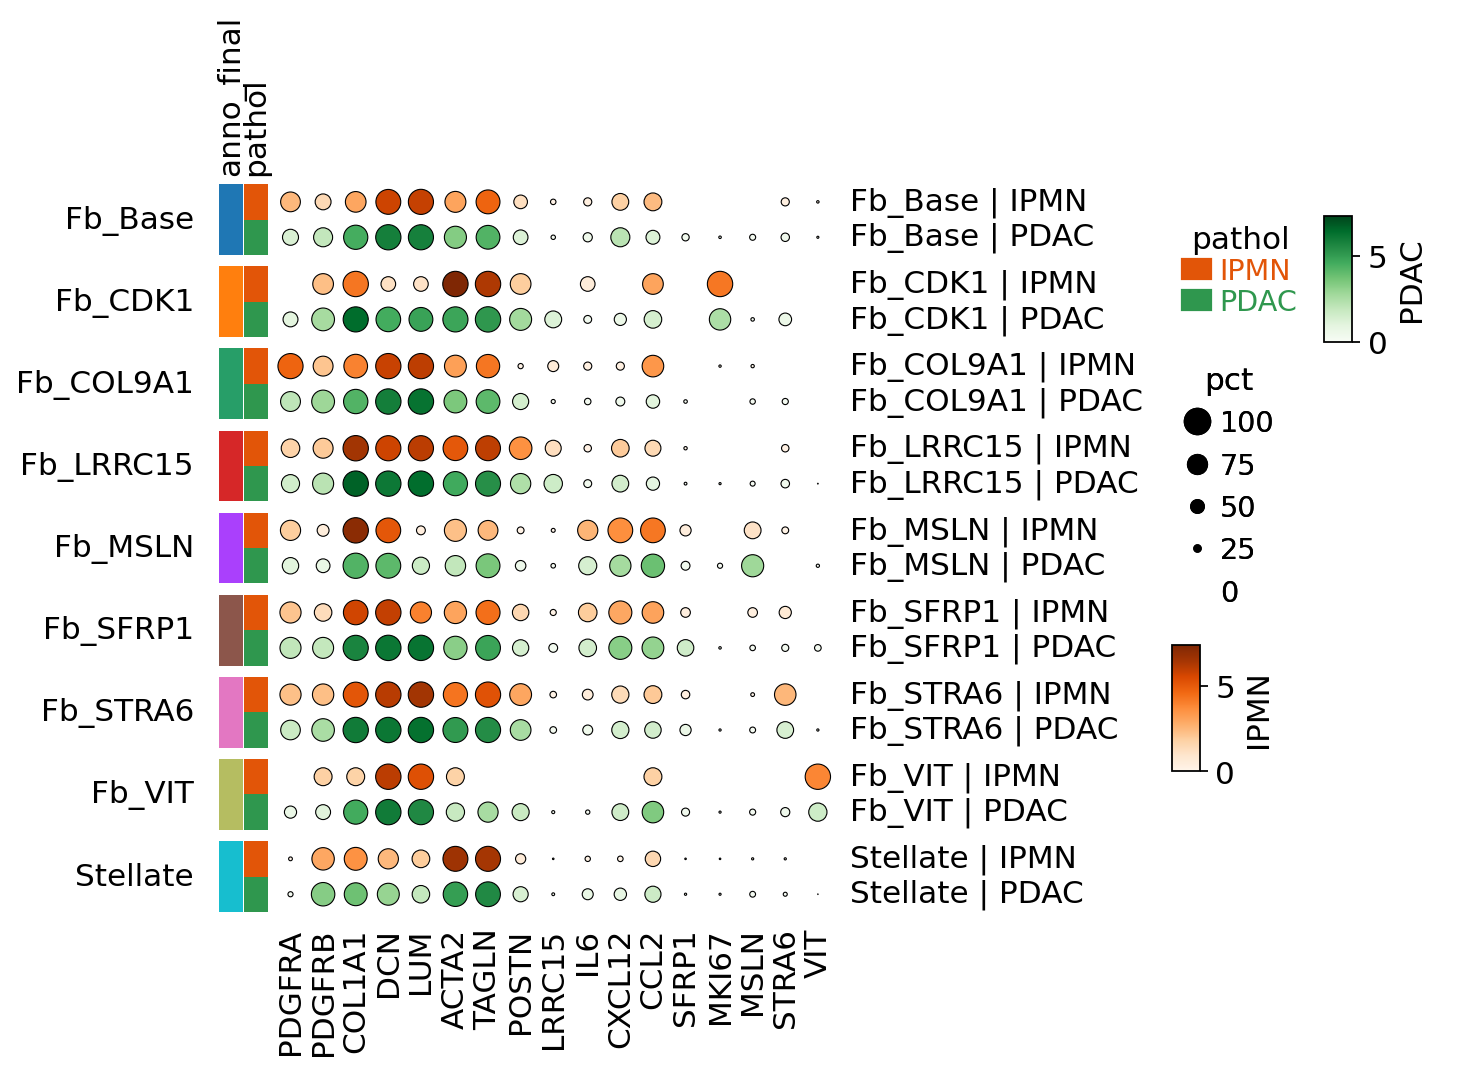

In [15]:
# label every sub-row and widen the legend column
fig, cm = scl.category_dotplot(adata, panel, groupby="anno_final", category="pathol",
                               show_rownames=True, legend_width=45)

## Cheat-sheet

| goal | argument |
|---|---|
| color = max-scaled 0..1 (per category) | `max_scale=True` |
| color = z-scored | `standard_scale='var'` / `'group'` |
| color limits | `vmin=`, `vmax=` |
| per-category colormaps | `category_cmaps={level: cmap}` (or list) |
| sidebar colors | `group_colors={level: color}` (else `uns` colors) |
| dot outline | `edgecolors=`, `linewidth=` (`'none'` / `0` to remove) |
| dot size | `max_s=`, `min_s=`, `dot_size='pct'`/`'mean'` |
| dot-size scale | `size_range=(0, 100)` for absolute % (default: 0→rounded max, scanpy-style) |
| row / column gaps | `row_split_gap=`, `col_split_gap=` |
| figure size | `figsize=(w, h)` |
| hide empty combos | `drop_empty=True` |
| x label angle | `xticklabels_kws={'labelrotation': deg}` |
| colorbar ticks / format | `cmap_legend_kws={'ticks': [...]}` / `{'format': '%.2f'}` |
| show all row labels | `show_rownames=True` |
| legend width / box | `legend_width=`, `*_legend_kws={'frameon': True}` |
| drop left annotations | `sidebar=False`, `show_group_label=False` |

Save a figure with `fig.savefig("out.pdf", bbox_inches="tight")`, or pass
`save="out.pdf"`.